In [25]:
from qiskit import *
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [26]:
circuit = QuantumCircuit(2, 2)

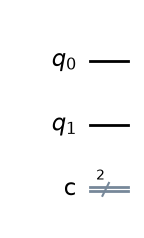

In [27]:
circuit.draw(output="mpl")

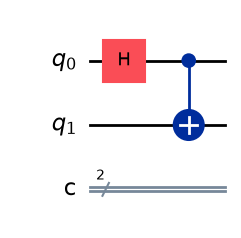

In [28]:
circuit.h(0)
circuit.cx(0, 1)
circuit.draw(output="mpl")

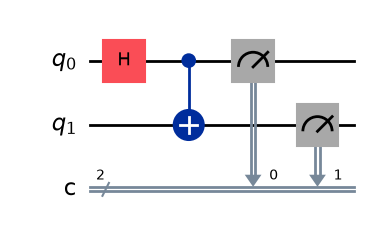

In [29]:
circuit.measure([0, 1], [0, 1])
circuit.draw(output="mpl")

In [30]:
simulator = AerSimulator()
result = simulator.run(circuit, shots=1024).result()
counts = result.get_counts()

In [31]:
print(counts)

{'00': 472, '11': 552}


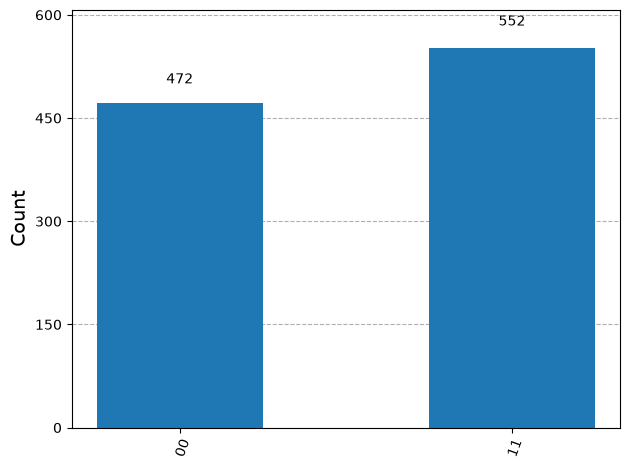

In [32]:
plot_histogram(counts)

In [33]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

for backend in service.backends():
    try:
        qubit_count = backend.num_qubits
    except:
        qubit_count = "unknown"
    
    print(f"{backend.name} : {backend.status().pending_jobs} & {qubit_count} qubits")

qiskit_runtime_service.__init__:WARNING:2026-09-16 15:58:03,881: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-16 15:58:03,893: Loading instance: open-instance, plan: open


ibm_fez : 245 & 156 qubits
ibm_marrakesh : 17 & 156 qubits
ibm_kingston : 114 & 156 qubits


In [37]:
quantum_computer = service.backend("ibm_marrakesh")

qiskit_runtime_service.backends:WARNING:2026-09-16 16:00:22,685: Using instance: open-instance, plan: open


In [38]:
from qiskit_ibm_runtime import SamplerV2

transpiled_circuit = transpile(circuit, quantum_computer)
sampler = SamplerV2(mode=quantum_computer)
job = sampler.run([transpiled_circuit], shots=1024)

In [43]:
print(job.status())

DONE


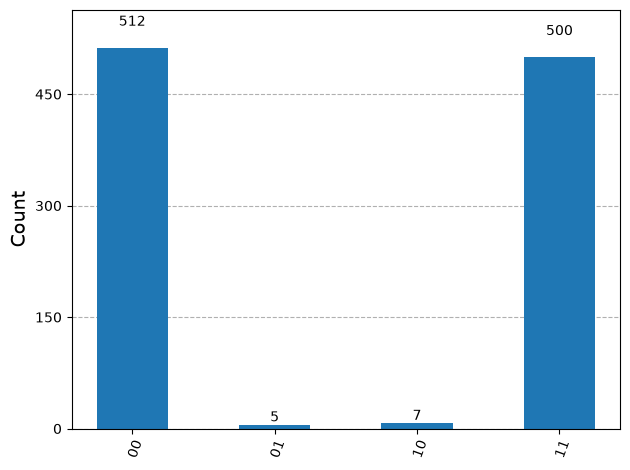

In [46]:
result = job.result()
counts = result[0].data.c.get_counts()

In [ ]:
plot_histogram(counts)